In [1]:
from Imports import *
from Plotting import *
from Helper import *
from Preprocessing import *

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
jet_images_path = '../../QuGAN/data/jet-images_Mass60-100_pT250-300_R1.25_Pix25.hdf5'
jet_mass_data = HDF5File(jet_images_path, 'r')

print(jet_mass_data.keys())
print(jet_mass_data['image'].shape)

<KeysViewHDF5 ['image', 'jet_delta_R', 'jet_eta', 'jet_mass', 'jet_phi', 'jet_pt', 'signal', 'tau_1', 'tau_2', 'tau_21', 'tau_3', 'tau_32']>
(872666, 25, 25)


[-3.84165387e-05-2.70170808e-01j  2.39481351e-02-1.77667171e-01j
  8.12812170e-02-1.59788925e-01j  8.12812170e-02-1.59788925e-01j
 -3.17626443e-02+1.63217564e-02j -1.73168718e-05+1.28470948e-04j
 -5.87743641e-05+1.15543207e-04j -5.87743641e-05+1.15543207e-04j
  9.47424743e-02+6.31356216e-02j  1.84728388e-01+5.47321114e-02j
  1.56287132e-01+1.12669932e-01j  1.56287132e-01+1.12669932e-01j
  1.01830216e-02+3.20457722e-02j -1.33576906e-04-3.95767332e-05j
 -1.13011064e-04-8.14715115e-05j -1.13011064e-04-8.14715115e-05j
  1.68180882e-05+1.18276051e-01j -1.04840744e-02+7.77795775e-02j
 -3.55834941e-02+6.99527944e-02j -3.55834941e-02+6.99527944e-02j
  1.39051297e-02-7.14537926e-03j  7.58102335e-06-5.62423322e-05j
  2.57303878e-05-5.05827934e-05j  2.57303878e-05-5.05827934e-05j
 -4.14765969e-02-2.76396700e-02j -8.08708547e-02-2.39607604e-02j
 -6.84197708e-02-4.93249241e-02j -6.84197708e-02-4.93249241e-02j
 -4.45794863e-03-1.40290781e-02j  5.84776315e-05+1.73260011e-05j
  4.94742656e-05+3.566680

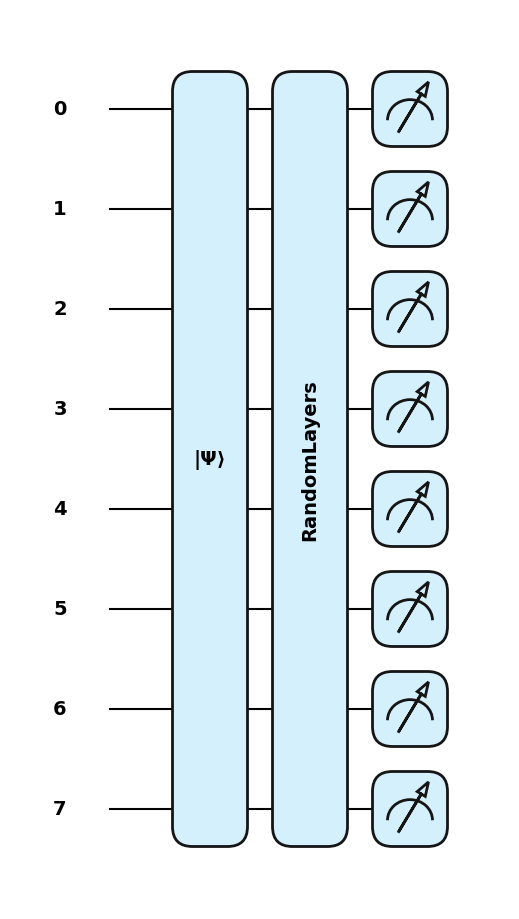

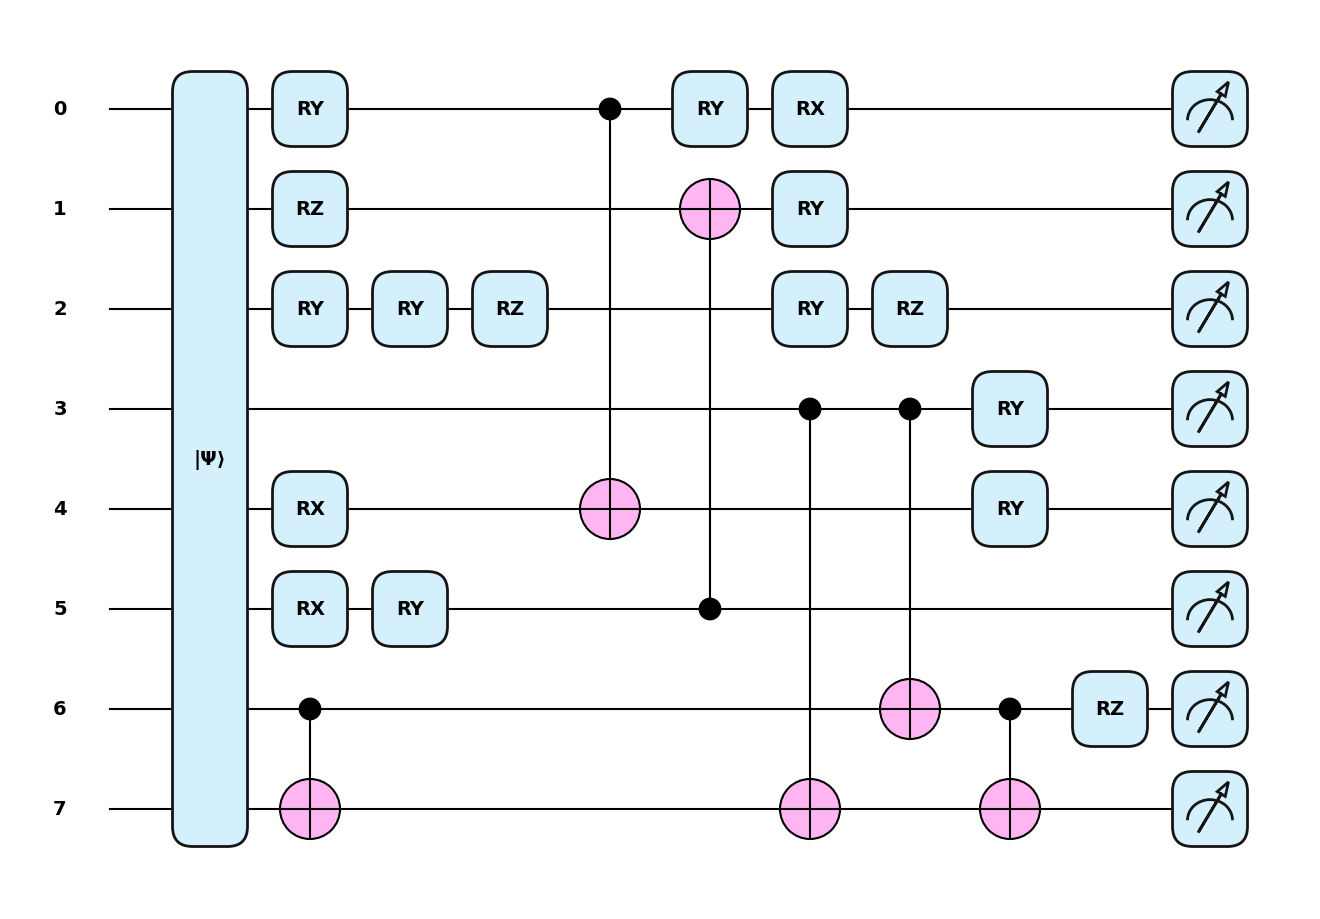

In [3]:
dev = qml.device("default.qubit", wires=8)
n_layers = 1

# Random circuit parameters
rand_params = np.random.uniform(high=2 * np.pi, size=(n_layers, 16))

@qml.qnode(dev)
def quantum_feature_embedding(f, phi, interface="torch", diff_method="backprop", cachesize=1000000):
    qml.AmplitudeEmbedding(features=f, wires=range(8), normalize=True, pad_with=0.)

    # Random quantum circuit
    RandomLayers(rand_params, wires=list(range(8)), seed = 6)

    # Measurement producing classical output values
    return qml.state()
    # return [qml.expval(qml.PauliZ(j)) for j in range(4)]

state = quantum_feature_embedding(f=[1/4, 1/4, 1/4, 1/4, 1/4, 1/4, 1/4, 1/4, 1/4], phi=rand_params)
print(state)

def quantum_feature_embedding_batch(x_batch, phi, device="cuda"):
    """
    Applies quantum_feature_embedding_single to a batch of inputs.

    Args:
        x_batch (torch.Tensor): (B, D) input batch.
        phi (np.ndarray or torch.Tensor): parameters for RandomLayers.
        device (str): Device to return output on.

    Returns:
        torch.Tensor: Output of shape (B, 2 ** n_qubits)
    """
    outputs = []
    for x in x_batch:
        result = quantum_feature_embedding(x, phi)
        result_tensor = result.real.to(device)
        outputs.append(result_tensor)

    return torch.stack(outputs)

sample = torch.randn(16, 9).to("cuda")  # Example batch
phi_tensor = torch.tensor(rand_params, dtype=torch.float32)

output = quantum_feature_embedding_batch(sample, phi_tensor)
print(output.shape)

class quantum_feature_embedding_batch(nn.Module):
    def __init__(self, device="cuda"):
        super().__init__()
        self.phi = nn.Parameter(torch.tensor(np.random.uniform(high=2 * np.pi, size=(n_layers, 3)), dtype=torch.float32))
    
    def forward(self, x_batch):
        phi = self.phi
        outputs = []
        for x in x_batch:
            result = quantum_feature_embedding(x, phi)
            result_tensor = result.real.to(device)
            outputs.append(result_tensor)
    
        return torch.stack(outputs)

qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl(quantum_feature_embedding)(f=[1/4]*9, phi=rand_params)
fig, ax = qml.draw_mpl(quantum_feature_embedding, level="device")(f=[1/4]*9, phi=rand_params)

In [4]:
# Generator with Quantum Layer
class Generator(nn.Module):
    def __init__(self, latent_dim=9):
        super().__init__()

        self.noise = GaussianNoise(sigma=0.1)
        
        self.feature_gen = quantum_feature_embedding_batch()

        self.image_gen1 = nn.Sequential(
            self.noise,
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 1x1 → 2x2
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )
        self.image_gen2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 2x2 → 4x4
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )
        self.image_gen3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),     # 4x4 → 8x8
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )

        self.image_gen4 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),     # 8x8 → 16x16
            nn.Sigmoid()
        )

    def forward(self, z_feat):
        img = self.feature_gen(z_feat).float()
        # print(img.shape)
        img = img.view(-1, 256, 1, 1)
        # print(img.shape)
        img = self.image_gen1(img)
        # print(img.shape)
        img = self.image_gen2(img)
        # print(img.shape)
        img = self.image_gen3(img)
        # print(img.shape)
        img = self.image_gen4(img)
        # print(img.shape)
        img = soft_threshold(img, threshold=0.001, sharpness=1000.0)
        return img


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
                # Flattened image: 16x16 = 256
        self.image_encoder = nn.Sequential(
            spectral_norm(nn.Conv2d(1, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            nn.Flatten()
        )

        self.feature_encoder = nn.Sequential(
            nn.Linear(4, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )

        # Dynamically get input dimensions
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 16, 16)
            flat_dim = self.image_encoder(dummy).shape[1] + 64

        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
   
    def forward(self, img, features):
        img_encoded = self.image_encoder(img)
        feat_encoded = self.feature_encoder(features)
        combined = torch.cat((img_encoded, feat_encoded), dim=1)

        # print(img_encoded.shape)
        # print(feat_encoded.shape)
        # print(combined.shape[-1])

        prob = self.classifier(combined)

        return prob  # Shape: (batch_size, 1)

Image shape: torch.Size([43633, 16, 16])
dR Mean: torch.Size([43633])
dR STD: torch.Size([43633])
Pixel Mean: torch.Size([43633])
Pixel STD: torch.Size([43633])
ΔR min: 0.0
ΔR max: 2.265674114227295
ΔR mean min: 0.0042752958834171295
ΔR mean max: 0.01479329913854599
ΔR std min: 0.02181866206228733
ΔR std max: 0.14948226511478424
Weights (pixel intensity) min: 0.0
Weights (pixel intensity) max: 1.0
Pixel mean min: 0.0029057813808321953
Pixel mean max: 0.004424060694873333
Pixel std min: 0.009593216702342033
Pixel std max: 0.06260580569505692


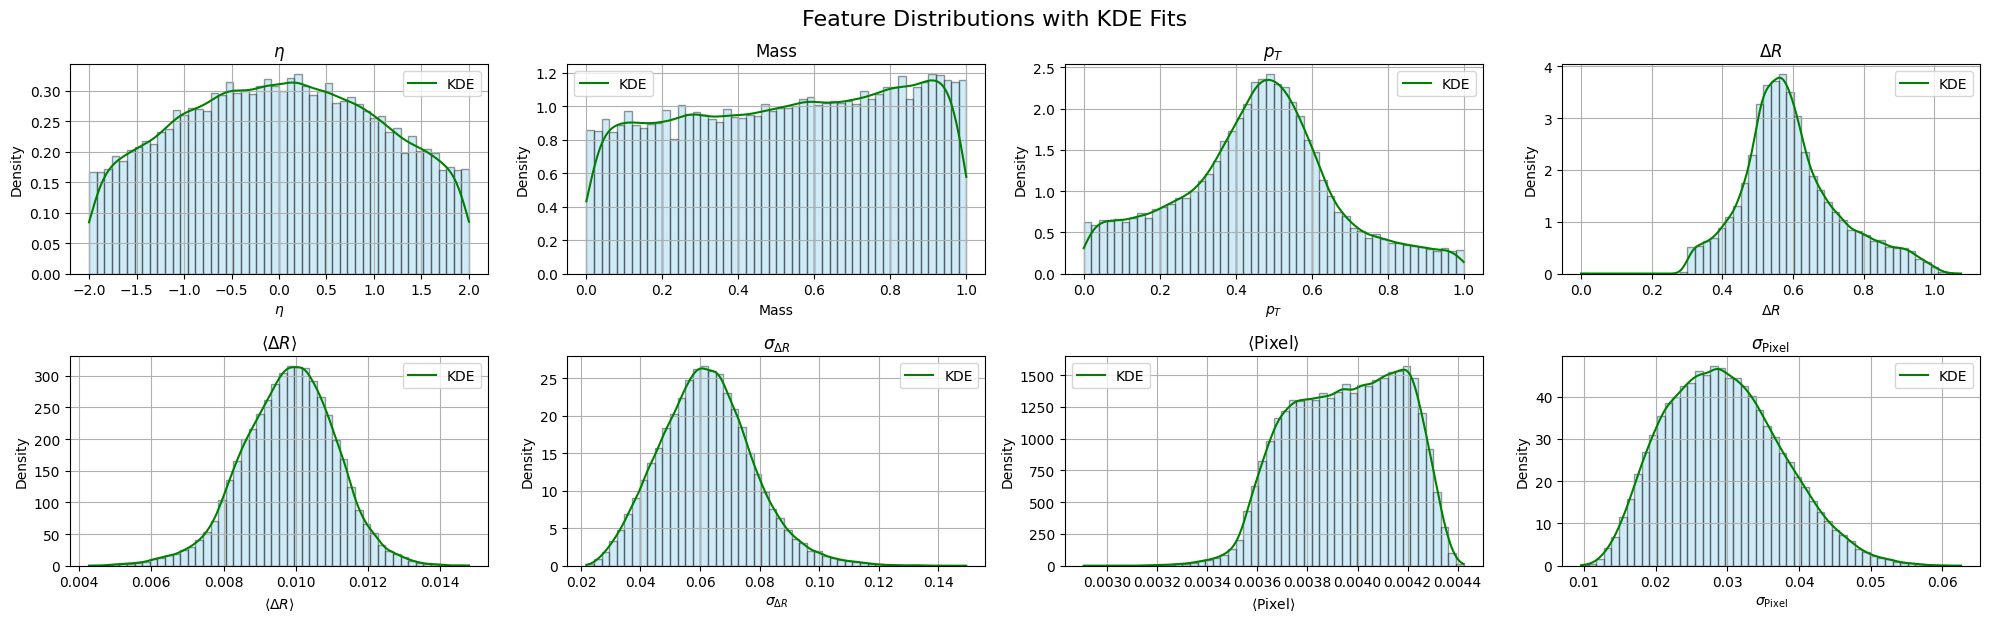

Number of samples: 43633
Image shape: torch.Size([43633, 16, 16])
Feature shape: torch.Size([43633, 9])


In [5]:
batch_size = 128
n_events = int(.05 * jet_mass_data['image'].shape[0])

latent_dim = 256
lr = 1e-3
n_epochs = 100
num = 4

dataset = JetDataset(jet_mass_data, n_events)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

kdes = feature_distributions(dataset)

print("Number of samples:", len(dataset))
print("Image shape:", dataset.images.shape)
print("Feature shape:", dataset.features.shape)

In [6]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.9, 0.999))
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.9, 0.999))

scheduler_G = CosineAnnealingLR(optimizer_G, T_max=n_epochs, eta_min=1e-4)
scheduler_D = CosineAnnealingLR(optimizer_D, T_max=n_epochs, eta_min=1e-4)

g_losses = []
d_losses = []

# Tracking buffers
stats_dict = {
    'fake_dR_mean': [],
    'fake_dR_std': [],
    'fake_pixel_mean': [],
    'fake_pixel_std': [],
    'real_dR_mean': [],
    'real_dR_std': [],
    'real_pixel_mean': [],
    'real_pixel_std': []
}

dists = compute_distance_map(16,16).to(device)

In [7]:
# graph =  draw_graph(
#     generator,
#     input_size=(1, 9),
#     expand_nested=True,
#     depth = 1,
#     graph_name="Discriminator Architecture",
#     mode = 'train',
#     show_shapes = True,
#     hide_inner_tensors=True,   # Hides intermediate shapes
#     roll=True,                  # More compact layer grouping
#     save_graph=False,           # Set to True if you want to save
#     # node_attr={"color": "lightblue", "style": "filled"},  # Node styling
#     # edge_attr={"color": "gray"},                          # Edge styling
#     graph_dir= "TB",                         # Layout: TB (top-bottom), LR (left-right)
# )

# # Show in notebook
# graph.visual_graph

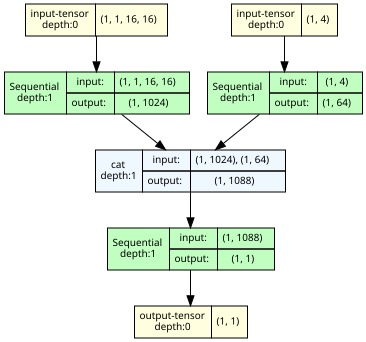

In [8]:
graph2 = draw_graph(
    discriminator,
    input_size=[(1, 1, 16, 16),(1,4)],
    expand_nested=True,
    depth = 1,
    graph_name="Discriminator Architecture",
    mode = 'train',
    show_shapes = True,
    hide_inner_tensors=True,   # Hides intermediate shapes
    roll=True,                  # More compact layer grouping
    save_graph=False,           # Set to True if you want to save
    # node_attr={"color": "lightblue", "style": "filled"},  # Node styling
    # edge_attr={"color": "gray"},                          # Edge styling
    graph_dir= "TB",                         # Layout: TB (top-bottom), LR (left-right)
)
graph2.visual_graph

In [12]:
## Load a previous model
# Replace with the desired filename
load = True

if load:
    # load_path = "models/QGAN_best_model_0722_1033.pt" # Revert here if the night's training doesn't improve
    load_path = "models/QGAN_best_model_m21_1120.pt"
    
    # Load the checkpoint
    checkpoint = torch.load(load_path)
    
    # Restore model weights
    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    
    # Optionally restore tracking data
    g_losses = checkpoint["g_losses"]
    d_losses = checkpoint["d_losses"]
    
    stats_dict = checkpoint["stats_dict"]
    
    print(f"Loaded model from {load_path}")

Loaded model from models/QGAN_best_model_m21_1120.pt


[Epoch 1/100] [D loss: 0.5529] [G loss: 1.2934] [Validity_loss: 1.0418] 
 [Stat_loss: 0.1976] [NNZ_loss: 0.0540]
Sample feature coding: [0.         0.7165191  0.10202939 0.4934274  0.37997365 0.00954747
 0.03851228 0.00370328 0.04610556]


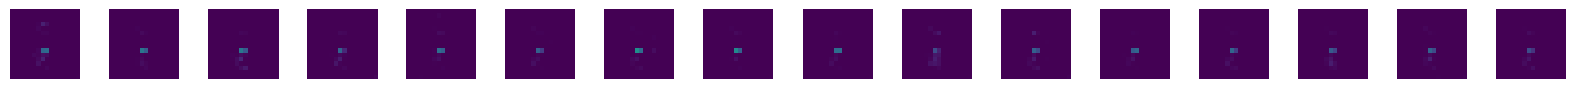

Model and statistics saved to models/class_gan_model_temp.pt


In [ ]:
if True:
    for epoch in range(n_epochs):
        for i, (real_image, real_features, flipped_image, flipped_features) in enumerate(dataloader):
            
            # All real data are normalized in the dataloader
            real_feat = real_features.to(device)
            real_flipped_feat = flipped_features.to(device)
            real_img = real_image.unsqueeze(1).to(device)
            real_flipped_img = flipped_image.unsqueeze(1).to(device)
    
            # print(f"Real: {real_img.shape}")
    
            # Codings will be label, eta, pT, mass that get passed directly to the discriminator
            # All feature values get passed to the generator, then the output image passed to the discriminator
    
            # Discriminator training
            if i % 3 == 0:
                optimizer_D.zero_grad()
                discriminator.train()
                # Generate fake samples
                # Should be very easy to modify which values are passed as codings
                z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                                      sample_fit_noise(kdes, num_samples=batch_size)[:,:]],
                                      dim=1).to(device)

                # Generate the fake image
                fake_img = generator(z_codings)
                # print(f"Fake: {fake_img.shape}")
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1

                fake_flipped_img = generator(flipped_z_codings)
    
                # Get predictions and labels
                real_disc_codings = real_feat[:,:num]
                real_flipped_disc_codings = real_flipped_feat[:,:num]
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]

                # Discriminator gets codings + image
                real_pred = discriminator(real_img, real_disc_codings)
                real_flipped_pred = discriminator(real_flipped_img, real_flipped_disc_codings)
                fake_pred = discriminator(fake_img, fake_disc_codings)
                fake_flipped_pred = discriminator(fake_flipped_img, fake_flipped_disc_codings)
    
                preds = (torch.cat([real_pred, real_flipped_pred, fake_pred, fake_flipped_pred], dim=0)).squeeze(1)

                # Labels
                ones = torch.ones(2*len(fake_pred))
                zeros = torch.zeros(2*len(real_pred))
                labels = (torch.cat([ones, zeros], dim=0)).to(device)
    
                # Discriminator loss is just its ability to distinguish
                d_loss = torch.nn.BCELoss()(preds, labels)
    
                d_loss.backward()
                optimizer_D.step()
    
            # Generator Training
            if i % 1 == 0:
                optimizer_G.zero_grad()
                generator.train()
                
                # Generate fake data
                # Should be very easy to modify which values are passed as codings
                z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                                      sample_fit_noise(kdes, num_samples=batch_size)[:,:]],
                                      dim=1).to(device)
    
                # Generate image
                fake_img = generator(z_codings)
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1

                fake_flipped_img = generator(flipped_z_codings)

                ## BCE Discriminator Loss
                # Discriminator gets codings + generated image
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]

                # Get predictions and labels
                fake_pred = discriminator(fake_img, fake_disc_codings)
                fake_flipped_pred = discriminator(fake_flipped_img, fake_flipped_disc_codings)

                target = torch.ones_like(fake_pred)
                bce = nn.BCELoss()
                validity_loss = bce(fake_pred, target) + bce(fake_flipped_pred, target)
    
                ## Stat loss
                # Compute statistics for original and flipped fake images
                fake_stats_orig = compute_fake_statistics(fake_img.to('cpu'), dists.to('cpu'))
                fake_stats_flip = compute_fake_statistics(fake_flipped_img.to('cpu'), dists.to('cpu'))
                
                # Average the statistics
                fake_stats = {
                    'fake_dR_mean': 0.5 * (fake_stats_orig['fake_dR_mean'] + fake_stats_flip['fake_dR_mean']),
                    'fake_dR_std': 0.5 * (fake_stats_orig['fake_dR_std'] + fake_stats_flip['fake_dR_std']),
                    'fake_pixel_mean': 0.5 * (fake_stats_orig['fake_pixel_mean'] + fake_stats_flip['fake_pixel_mean']),
                    'fake_pixel_std': 0.5 * (fake_stats_orig['fake_pixel_std'] + fake_stats_flip['fake_pixel_std']),
                }
                
                # Move to device
                fake_dR_mean = fake_stats['fake_dR_mean'].to(device)
                fake_dR_std = fake_stats['fake_dR_std'].to(device)
                fake_pixel_mean = fake_stats['fake_pixel_mean'].to(device)
                fake_pixel_std = fake_stats['fake_pixel_std'].to(device)
                
                # Get real stats from z_codings (features 5–8)
                real_dR_mean = z_codings[:,5]
                real_dR_std = z_codings[:,6]
                real_pixel_mean = z_codings[:,7]
                real_pixel_std = z_codings[:,8]
                
                real_stats = {
                    'real_dR_mean': real_dR_mean,
                    'real_dR_std': real_dR_std,
                    'real_pixel_mean': real_pixel_mean,
                    'real_pixel_std': real_pixel_std
                }
                
                # stats_dict = track_statistics(fake_stats, real_stats)
                # plot_tracked_statistics(stats_dict)
                
                if n_epochs - epoch <= 10:
                    # Track the last statistics
                    stats_dict = track_statistics(fake_stats, real_stats)
                    plot_tracked_statistics(stats_dict)
                
                # Statistical KL Divergence loss
                kl_total = 0
                kl1 = kde_kl_divergence_torch(real_dR_mean / batch_size, fake_dR_mean) / 0.000003
                # print(f"KL(real_dR_mean, fake_dR_mean) = {kl1.item()}")
                
                kl2 = kde_kl_divergence_torch(real_dR_std / batch_size, fake_dR_std) / 0.003
                # print(f"KL(real_dR_std, fake_dR_std) = {kl2.item()}")
                
                kl3 = kde_kl_divergence_torch(real_pixel_mean / batch_size, fake_pixel_mean) / 0.00000007
                # print(f"KL(real_pixel_mean, fake_pixel_mean) = {kl3.item()}")
                
                kl4 = kde_kl_divergence_torch(real_pixel_std / batch_size, fake_pixel_std) / 0.0005
                # print(f"KL(real_pixel_std, fake_pixel_std) = {kl4.item()}")
                
                kl_total = kl1 + kl2 + kl3 + kl4
    
                stat_loss = kl_total

                # Number non-zero loss
                fake_nnz = soft_count_nonzero(fake_img, threshold=3e-3, sharpness=10000.0)
                real_nnz = soft_count_nonzero(real_img, threshold=3e-3, sharpness=10000.0)
                nnz_loss = torch.nn.MSELoss()(fake_nnz, real_nnz)
    
                
                # Total generator loss is the average of the discriminator's predictions of the original and flipped data
                # + number of non-zero pixels loss
                # + the difference between input and output dR and pixel statistics
    
                alpha = .4
                beta = .001
                chi = .03
    
                g_loss = (alpha*validity_loss + beta*nnz_loss + chi*stat_loss)

                g_loss.backward()
                optimizer_G.step()
    
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        print(f"[Epoch {epoch+1}/{n_epochs}] [D loss: {d_losses[-1]:.4f}] [G loss: {g_losses[-1]:.4f}] [Validity_loss: {alpha*validity_loss:.4f}] \n [Stat_loss: {chi*stat_loss:.4f}] [NNZ_loss: {beta*nnz_loss:.4f}]") 

        plot_generated_samples(generator, dataset, kdes, batch_size=16, latent_dim=256)

        if epoch % 10 == 0:
            # Save model states and tracked data in a temp file during training
            save_path = f"models/class_gan_model_temp.pt"
            torch.save({
                "generator_state_dict": generator.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "g_losses": g_losses,
                "d_losses": d_losses,
                "stats_dict": stats_dict
            }, save_path)

            print(f"Model and statistics saved to {save_path}")

In [11]:
## Save Model
# Create output directory if it doesn't exist
save = True

if save:
    os.makedirs("models", exist_ok=True)
    
    # Timestamp for unique filenames
    timestamp = datetime.now().strftime("%m%d_%H%M")
    
    # Save model states and tracked data in a single file
    save_path = f"models/QGAN_best_model_{timestamp}.pt"
    torch.save({
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "g_losses": g_losses,
        "d_losses": d_losses,
        "stats_dict": stats_dict
    }, save_path)
    
    print(f"Model and statistics saved to {save_path}")

Model and statistics saved to models/QGAN_best_model_0724_1001.pt


![image.png](attachment:7aee3b98-579c-4bcb-9682-eb417b7e3a7a.png)

In [ ]:
plot_real_samples(dataset)

Sample feature coding: [1.         1.4357293  0.4551238  0.30645207 0.76146317 0.00784044
 0.06369489 0.00397259 0.02997088]


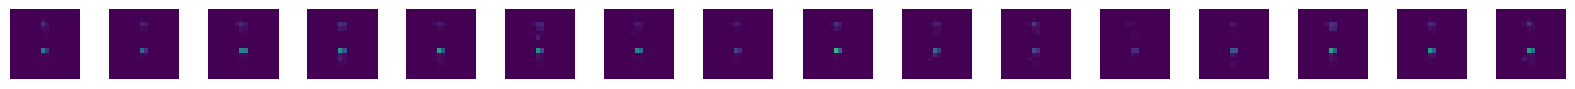

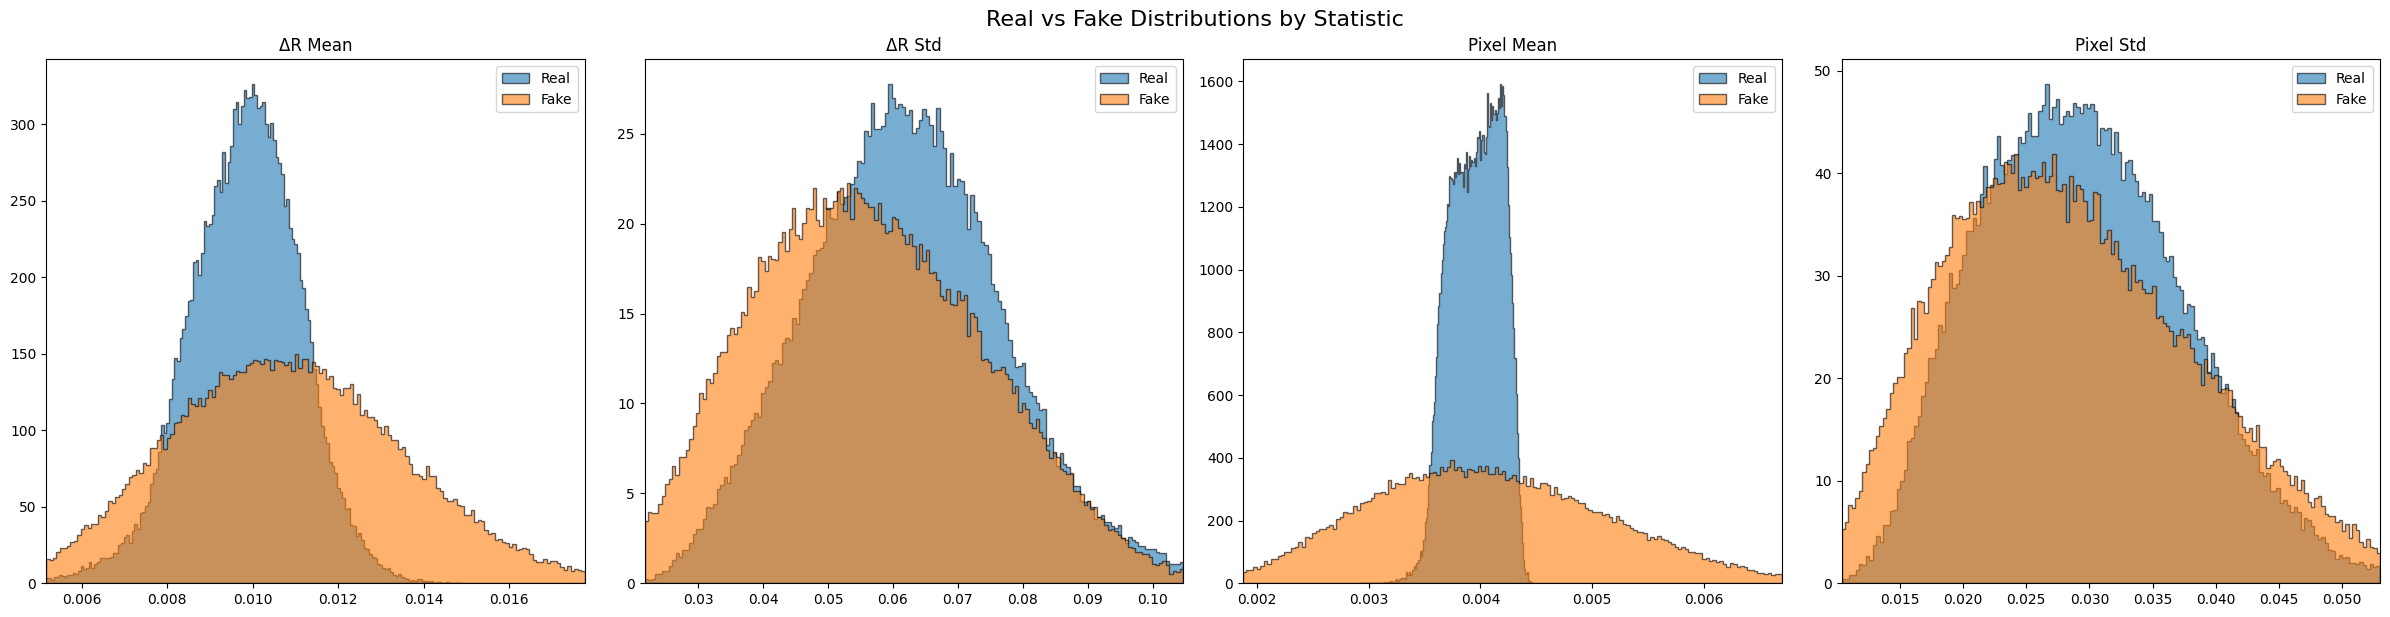

Discriminator output (wrong label): [0.41505793 0.33347416 0.366933   ... 0.35801768 0.3357799  0.37152645]
Discriminator output (correct label): [0.51641196 0.57514673 0.5506132  ... 0.5549074  0.5680685  0.52557963]
Real labels: [1. 1. 1. ... 1. 1. 1.]
Swapped labels: [0. 0. 0. ... 0. 0. 0.]
Relative change (%): [-19.626587 -42.01929  -33.35921  ... -35.48154  -40.89095  -29.311102]


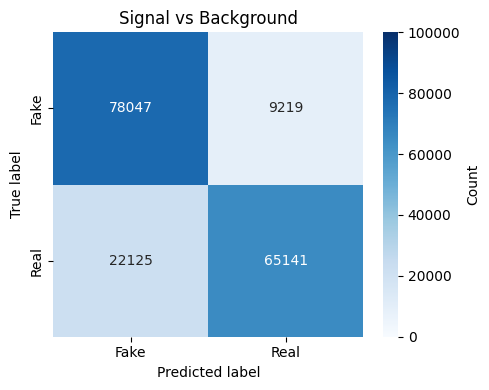

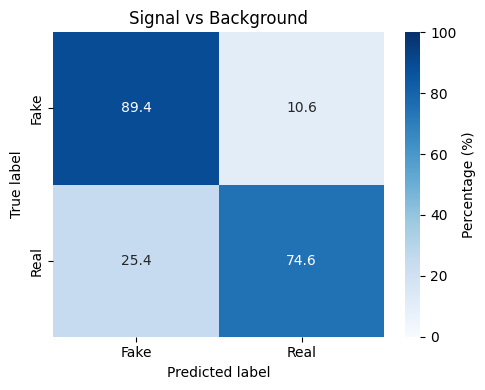

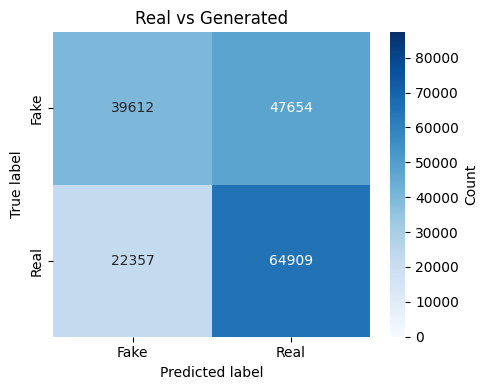

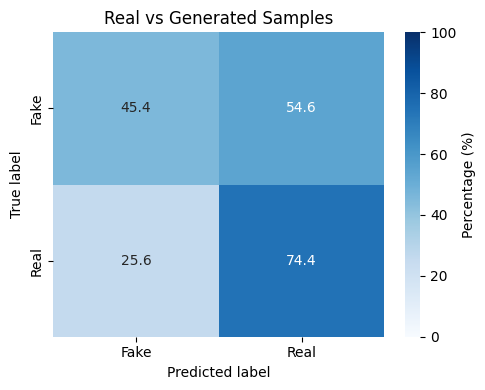

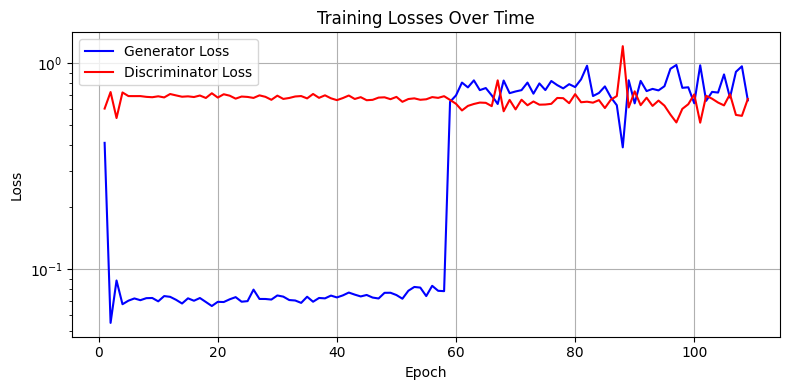

In [14]:
test_generated_samples(generator, discriminator, dataset, kdes, batch_size=100000)

# Optional args:
#     generator,
#     discriminator,
#     dataset,
#     kdes,
#     batch_size=16,
#     latent_dim=256,
#     codings=None,
#     plot_distributions=True,
#     compare_discriminator=True

plot_metrics(g_losses, d_losses)